<h1 align="center">Física Computacional.</h1>
<h1 align="center">Semestre 2027-1</h1>

<h2>Franco Olvera Ángel Jesús </h2> 

---


<h1 align="center">Programación para la física computacional</h1> 

## Práctica 3.  Graficación en Python

---

### **EJERCICIOS**:

$\;$

### **1.  Gráfica de datos experimentales** 
 El archivo manchasolares.txt (adjunto), contiene el numero observado de manchas solares en el Sol en cada mes desde enero de 1749. El archivo contiene dos columnas de numeros, la primera es el mes y la segunda el número de manchas solares.

 a) Escribe un programa que lea los datos y haga una grafica de las manchas solares en funcion del tiempo. 
#### 

In [2]:
import numpy as np
import matplotlib.pyplot as plt


Text(0, 0.5, 'Número de manchas')

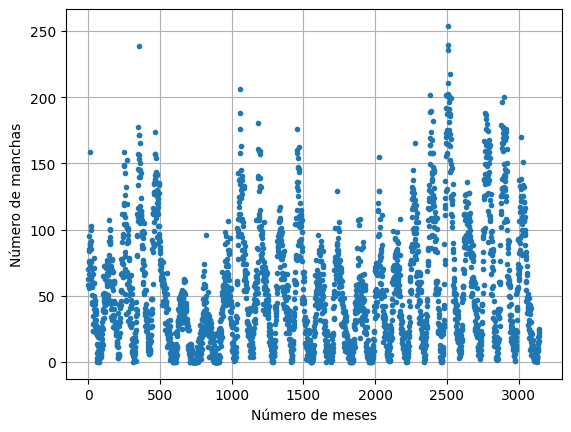

In [11]:
datos = np.loadtxt("manchasolares.txt")    #Abrir el archivo de datos

#Dividimos los datos en dos listas
mes = datos[:,0]
manchas= datos[:,1]

plt.plot(mes, manchas, ".")
plt.grid()
#Ponemos nombres a los ejes
plt.xlabel("Número de meses")
plt.ylabel("Número de manchas")


### 
b) Modifica tu programa para mostrar solo los primeros 1000 datos (experimentales) en la grafica.
#### 

In [12]:
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, 'Número de manchas')

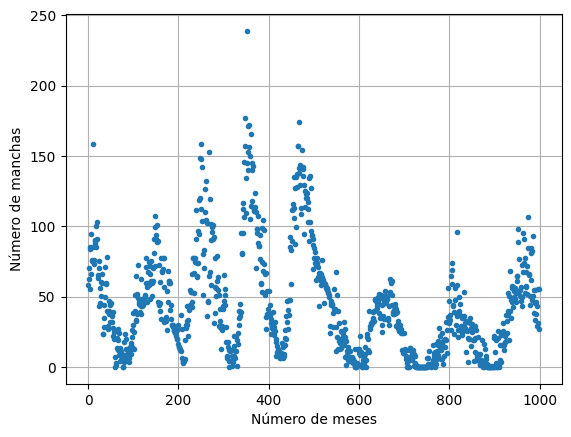

In [23]:
datos = np.loadtxt("manchasolares.txt")    #Abrir el archivo de datos

#Dividimos los datos en dos listas
mes = datos[:,0]
manchas= datos[:,1]

#Tomamos los primeros 1000 elementos de cada lista
x = mes[:1000]
y = manchas[:1000]

plt.plot(x, y, ".")
plt.grid()
#Ponemos nombres a los ejes
plt.xlabel("Número de meses")
plt.ylabel("Número de manchas")

### 
c) Modifica nuevamente tu programa para calcular y graficar la media (promedio) móvil de los datos, definida por:

$$
Y_k = \frac{1}{2r+1} \sum_{-r}^{r}y_{k+m}

$$

donde r = 5 (en este caso) y yk son los numeros de manchas solares. El programa debe graficar tanto los datos originales como la media móvil en el mismo gráfico, sólo sobre los primeros 1000 datos.
#### 

In [24]:
import numpy as np
import matplotlib.pyplot as plt

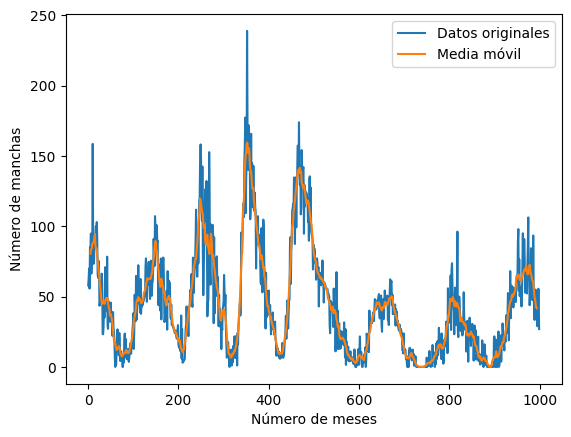

In [68]:
datos = np.loadtxt("manchasolares.txt")    #Abrir el archivo de datos

#Dividimos los datos en dos listas
mes = datos[:,0]
manchas= datos[:,1]

#Tomamos los primeros 1000 elementos de cada lista
y = mes[:1000]
x = manchas[:1000]

mediamovil =[] #Lista vacía para guardar las medias
mes_media =[]
#Calculamos la media movil
for k in range(5, 995): #Inicia en 5 ya que al hacer k+m, sólo en k=5 tenemos el primer elemento de la suma
    suma = 0

    for m in range (-5, 6):

        suma = suma + x[k+m]

        media=suma / (2*5 +1)

    #Agregamos el promedio.
    mediamovil.append(media)
    mes_media.append (y[k])

#Grafica de los primeros 1000 datos
plt.plot(y, x, label="Datos originales")

#Grafica de las medias móviles de los primeros 1000 datos
plt.plot(mes_media, mediamovil, label="Media móvil")

#Ponemos nombres a los ejes
plt.xlabel("Número de meses")
plt.ylabel("Número de manchas")

plt.legend()



### **2.  La gráfica de Feigenbaum (caos determinista)** 

En un especial halloween de los Simpsons, Homero viaja al pasado a la era Jurásica y
por un pequeño descuido cambia el curso de toda la historia en el futuro. Lo anterior
es una referencia al cuento *A Sound of Thunder* de 1952 del escritor de ciencia ficción
Ray Bradbury en donde lo que se destruye en el pasado es una mariposa. Esta idea
fue retomada y popularizada por el físico Edward Lorenz en 1972 cuando dio una
conferencia en la Asociación Estadounidense para el Avance de la Ciencia (*American
Association for the Advancement of Science*) titulada "¿El aleteo de una mariposa en Brasil
puede provocar un tornado en Texas?". Dando paso al concepto del **efecto mariposa**, del
cual probablemente hayas oído hablar y que es el ejemplo clásico de **caos determinista**
en sistemas climáticos. El caos determinista también aparece en muchos sistemas
físicos más complejos, incluyendo especialmente la dinámica de fluidos. Debido a su naturaleza aparentemente aleatoria, el comportamiento de los sistemas caóticos
es difícil de predecir y se ve fuertemente afectado por pequeñas perturbaciones en
las condiciones iniciales. Uno de los ejemplos más famosos del fenómeno del caos
determinista es sin duda el **mapeo logístico**, que es un sistema matemático muy simple,
definido por la ecuación:

$$x_{n+1} = r x_n (1 - x_n)$$

Para un valor dado de la constante $r$, se toma un valor de $x_n$ (digamos $x = \frac{1}{2}$) y se
introduce en el lado derecho de esta ecuación y regresa un valor de $x_{n+1}$. Luego se
toma ese valor y se vuelve a introducir en el lado derecho, lo que da otro valor, y así
sucesivamente. Esto es un mapeo iterativo. Se continúa haciendo la misma operación
una y otra vez sobre su valor de $x_n$, y entonces sucede una de las tres siguientes situaciones:

1. El valor se establece en un número fijo y permanece allí. Esto se llama **punto fijo**.
   Por ejemplo, $x_n = 0$ es siempre un punto fijo del mapeo logístico. (Si se pone
   $x_n = 0$ en el lado derecho se obtiene $x_{n+1} = 0$ en el lado izquierdo).

2. No se establece en un solo valor, sino que se establece en un patrón periódico,
   rotando alrededor de un conjunto de valores, digamos cuatro valores, repitiéndose
   en secuencia una y otra vez. Esto se llama **órbita** (en este caso de periodo 4) o **ciclo
   límite**.

3. Todo enloquece. El mapeo genera una secuencia aparentemente aleatoria de
   números que parecen no tener ni patrón ni razón (ni ton ni son). Esto es el **caos
   determinista**. "Caos" porque realmente parece caótico y "determinista" porque
   aunque los valores parecen aleatorios, no lo son. Son a todas luces, totalmente
   predecibles, porque se obtienen mediante una simple ecuación y el comportamiento
   está determinado, aunque no lo parezca.

## Responde a las siguientes preguntas:

**(a)** Apóyate en el programa que vimos en clase y escribe un programa que muestre
el comportamiento del mapeo logístico mediante una gráfica.

> **Hint:** Esto es lo que debes hacer para hacer tu programa:
>
> Para un valor dado de $r$, comienza con $x_n = \frac{1}{2}$ e itera la ecuación del mapeo
> logístico mil veces. Eso le dará la oportunidad de establecerse en un punto fijo o
> en una órbita de algún periodo. Luego ejecuta otras mil iteraciones y grafica los
> puntos $(r, x_\infty)$ en una gráfica donde el eje horizontal es $r$ y el eje vertical es $x_\infty$.
> Puedes usar la función `plot` con las opciones `"ko"` o `"k."` para dibujar una gráfica
> con puntos, uno para cada punto, o puedes usar la función `scatter` para dibujar
> un diagrama de dispersión (que siempre usa puntos). Repite todo el cálculo para
> valores de $r$ de 1 a 4 en pasos de 0.01, graficando los puntos para todos los valores de $r$ en la misma figura. Tu programa debería generar la distintiva gráfica que
> parece un árbol inclinado hacia un lado. Esta famosa imagen se llama **Gráfica de
> Feigenbaum**, en honor a su descubridor Mitchell Feigenbaum.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

C:\Users\franq\AppData\Local\Temp\ipykernel_15612\4219856595.py:14: RuntimeWarning: overflow encountered in scalar multiply
  x = r* x * (1-x)


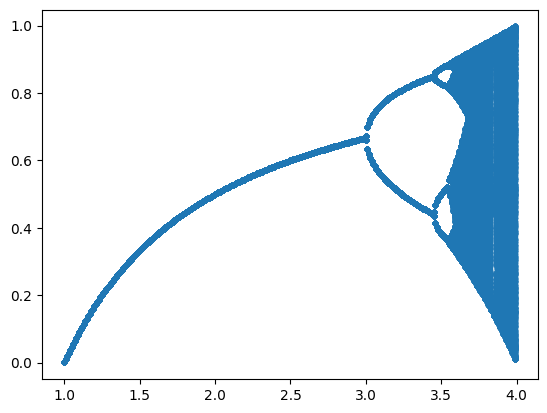

In [19]:
#Creamos dos listas vacías para ir guardando los datos.

r_graf= []
x_graf = []

#Hacemos los valores de r
for r in np.arange(1, 4.01, 0.01):

    #Inicia en 0.5
    x=0.5

#Hacer la operación mil veces una vez para que se establezca en un punto fijo.
    for i in range(1000):
        x = r* x * (1-x)

#Otras mil veces una vez para graficarlas.
    for i in range(1000):
        x = r* x*(1-x)
        x_graf.append(x)
        r_graf.append(r)

plt.plot(r_graf,x_graf, ".")

C:\Users\franq\AppData\Local\Temp\ipykernel_15612\1072137237.py:18: RuntimeWarning: overflow encountered in scalar multiply
  x = r*x*(1-x)


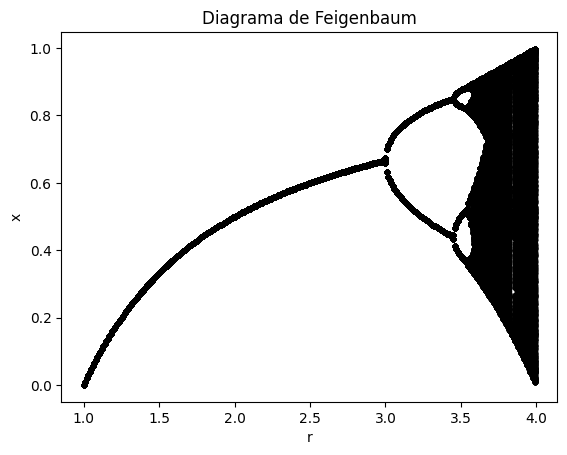

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Valores de r
valores_r = np.arange(1.0, 4.01, 0.01)

# Crear la gráfica
plt.figure()

# Repetir para cada valor de r
for r in valores_r:

    # Condición inicial
    x = 0.5

    # Primeras 1000 iteraciones
    for n in range(1000):
        x = r*x*(1-x)

    for n in range(1000):
        x = r*x*(1-x)
  
        # Graficar el punto (r,x)
        plt.plot(r, x, "k.")

# Etiquetas
plt.xlabel("r")
plt.ylabel("x")
plt.title("Diagrama de Feigenbaum")

plt.show()

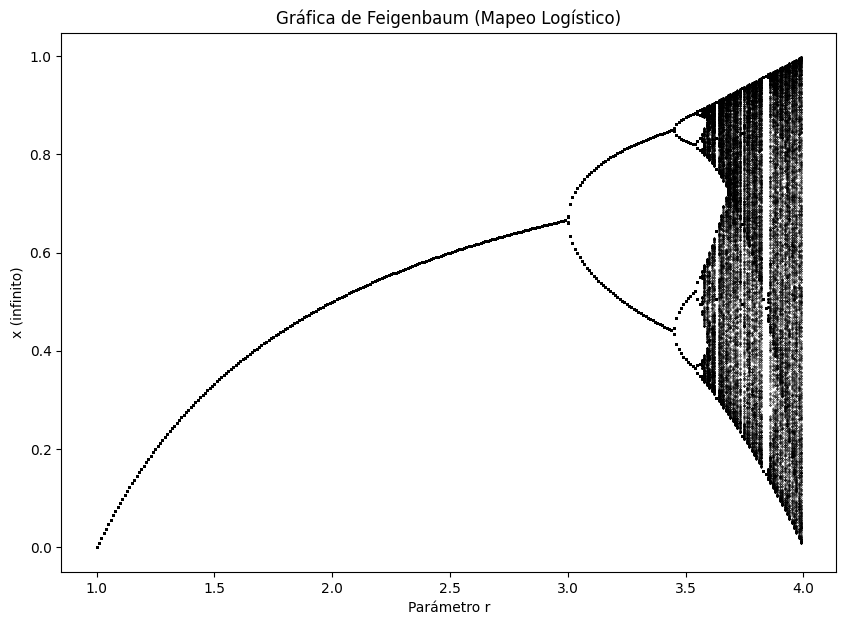

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Definir los valores de r de 1 a 4 en pasos de 0.01
r_valores = np.arange(1.0, 4.0, 0.01)
r_grafica = []
x_grafica = []

for r in r_valores:
    x = 0.5  # Condición inicial
    # Iterar 1000 veces para dejar que el sistema se estabilice
    for _ in range(1000):
        x = r * x * (1 - x)
    
    # Tomar las siguientes 1000 iteraciones para graficar
    for _ in range(1000):
        x = r * x * (1 - x)
        r_grafica.append(r)
        x_grafica.append(x)

# Generar la Gráfica de Feigenbaum
plt.figure(figsize=(10, 7))
plt.plot(r_grafica, x_grafica, 'k.', markersize=0.5)
plt.title('Gráfica de Feigenbaum (Mapeo Logístico)')
plt.xlabel('Parámetro r')
plt.ylabel('x (infinito)')
plt.show()

**(b)** De acuerdo a tu gráfica, ¿a qué valor de $r$ el sistema pasa de un comportamiento
ordenado (puntos fijos o ciclos límite) a un comportamiento caótico? A este punto
a veces se le llama “el borde del caos”.


**(c) \*\* Opcional (para 1.5 puntos extra):** Hay otra forma para calcular el diagrama
de Feigenbaum, que puede ser más claro y rápido, dado que hace uso de la
capacidad de Python para realizar aritmética con arreglos completos. Crear un
arreglo r que contenga cada valor distinto de $r$, [1.0, 1.01, 1.02, ...]. Crea
otro arreglo x del mismo tamaño para guardar los valores correspondientes de
$x$, establecidos inicialmente en 0.5; finalmente realiza una iteración del mapeo
logístico para todos los valores de $r$ a la vez, con una sola instrucción de la forma
x = r*x*(1-x) y compárala con tu programa anterior.

In [ ]:
import math as mt

In [ ]:
#Definimos las constantes a1, a2, a3, a4
a1=15.8
a2=18.3
a3=0.714
a4=23.2

 #Tomamos A=58 y Z=28
A=58
Z=28   

#Calculamos a5
if A % 2 != 0:
        a5=0
if A % 2 ==0 and Z % 2 ==0:
        a5=12
else:
    a5=-12


#Calcular B.
B = a1 * A -a2*(A**(2/3)) - a3 *((Z**2)/A**(1/3)) - a4 * (((A-2*Z)**2) / A) + a5 / A**(1/2)


print("La energía de enlace es: ", B, "Mev")

2.b) Modifica el programa del inciso anterior, para escribir una segunda version que imprima no la energía de enlace total B, sino la energia de union por nucleón, que es B/A.

In [ ]:
import math as mt

In [ ]:
#Definimos las constantes a1, a2, a3, a4
a1=15.8
a2=18.3
a3=0.714
a4=23.2

 #Tomamos A=58 y Z=28
A=58
Z=28   

#Calculamos a5
if A % 2 != 0:
        a5=0
if A % 2 ==0 and Z % 2 ==0:
        a5=12
else:
    a5=-12


#Calcular B.
B = a1 * A -a2*(A**(2/3)) - a3 *((Z**2)/A**(1/3)) - a4 * (((A-2*Z)**2) / A) + a5 / A**(1/2)

energianuc = B/A

print("La energía de unión por nucleón es: ", energianuc , "Mev")

2.c) Escribe una tercera versión del programa para que tome como entrada un solo valor del numero atómico Z y luego pase por todos los valores de A desde $A=Z$ hasta $A= 3Z$, para encotnrar el que tiene la mayor energía de enlace por nucleón. Este es el núcleo más estable con el número atómico dado. Haz que tu programa imprima el valor de A para este núcleo mas estable y el valor de la energía de enlace por nucleón.


In [ ]:
#Definimos las constantes a1, a2, a3, a4
a1=15.8
a2=18.3
a3=0.714
a4=23.2

Z= int(input("Introduce el valor de Z")) #Le pongo input para que se escoja el valor de Z, aunque podría omitirse y cambiar el código directamente xd

#Vamos guardando los valores para compararlos al final
energiamayor = 0
Amax = 0

for A in range(Z, 3*Z + 1):

    if A % 2 != 0:
        a5 = 0
    elif Z % 2 == 0:
        a5 = 12
    else:
        a5 =-12

#Calcular B. 
    B = a1 * A -a2*(A**(2/3)) - a3 *((Z**2)/A**(1/3)) - a4 * (((A-2*Z)**2) / A) + a5 / A**(1/2)


    energianuc = B / A


    if energianuc > energiamayor:
        energiamayor = energianuc
        Amax = A

print ("El A más estable es:", Amax)
print ("La energía de enlace por nucleón es:", energiamayor)



2.d) Finalmente, escribe una cuarta version del programa que, en lugar de tomar Z como entrada, se ejecute a traves de todos los valores de  Z de 1 a 100 e imprima el valor mas estable de  A para cada uno. ¿A qué valor de Z se produce la energía de enlace máxima por nucleón? (La respuesta correcta, en la vida real, es Z = 28, que corresponde al Níquel).

In [ ]:
import math as mt
#Definimos las constantes a1, a2, a3, a4
a1=15.8
a2=18.3
a3=0.714
a4=23.2

emayorglobal =0
Amaxglobal = 0
Zglobal = 0

for Z in range(1, 101):
    energiamayor = 0
    Amax = 0

    for A in range(Z, 3*Z + 1):
            
            if A % 2 != 0:
                a5 = 0
            elif Z % 2 == 0:
                a5 = 12
            else:
                a5 =-12

            #Calcular B. 
            B = a1 * A -a2*(A**(2/3)) - a3 *((Z**2)/A**(1/3)) - a4 * (((A-2*Z)**2) / A) + a5 / A**(1/2)


            energianuc = B / A

            if energianuc > energiamayor: #Comparar los resultados anteriores, y cuando se cumpla la condición, guardar ese
                energiamayor = energianuc
                Amax = A
    if energiamayor > emayorglobal :
        emayorglobal = energiamayor
        A_global = Amax
        Z_global = Z
    


print("Z que produce la energía máxima por nucleón es:", Z_global)
print("A =", A_global)
print("La energía de enlace por nucleón es:", emayorglobal, "MeV")

### **3. Coeficientes binomiales** 
El coeficiente binomial 
$$
    \binom{n}{k} = \frac{n!}{k!(n-k)!} = \frac{n \times (n-1) \times (n-2)\times...\times(n-k+1)}{1 \times 2\times...\times k}
$$ 

es un numero entero igual a:

$ $

donde $k \geqslant 1$ o bien $\binom{n}{0}=1$ cuando $k=0$

a) Utiliza esta fórmula para escribir una funcion llamada  binomial(n,k) (o como tu quieras) que calcule el coeficiente binomial para un n y k dados. Asegúrate de que tu funcion devuelva la respuesta en forma de un numero entero (no flotante) y proporcione el valor correcto de 1 para el caso en que k = 0.

In [ ]:
import math as mt

In [ ]:
#Definimos la funcion

def binomial(n,k):
    #Si k es cero, el resultado debe ser 1
    if k == 0:
        return 1
    
    binom = 1

    for i in range(1, k+1):
        binom = binom * (n-k+i) // i #Usamos // para que el resultado sea entero

    return binom


In [ ]:
binomial(5,4)


3.b) Usando tu funcion, escribe un programa que imprima las primeras 20 líneas del “triángulo de Pascal’’. La n-ésima línea del triaágulo de Pascal contiene  n + 1 numeros, que son los coeficientes $\binom{n}{0}$, $\binom{n}{1}$, y así sucesivamente hasta $\binom{n}{n}$. De tal manera que las primeras línes son:

1 1 $\\$
1 2 1 $\\$
1 3 3 1 $\\$
1 4 6 4 1 

In [ ]:
import math as mt

In [ ]:
def binomial(n,k):
    #Si k es cero, el resultado debe ser 1
    if k == 0:
        return 1
    
    binom = 1

    for i in range(1, k+1):
        binom = binom * (n-k+i) // i #Usamos // para que el resultado sea entero

    return binom
#Queremos n líneas hasta n=20
for n in range(1,21):

    for k in range(n+1):      #Inicialmente sale todo en vertical, así que reddit dice que se arregla poniendo end=""
        print(binomial(n,k), end="  ") 

    print()

3.c) La probabilidad de que para una moneda no sesgada, lanzada n veces, salga águila k veces es:

$$
p(k|n) = \frac{\binom{n}{k}}{2^n}
$$

Escribe un programa para calcular: $\\$
    1) la probabilidad total de que una moneda lanzada 100 veces, salga águila exactamente 60 veces y $\\$
    2) la probabilidad de que salga águila 60 veces o más.



In [ ]:
#Usamos el mismo programa, pero definimos los valores de n y k
def binomial(n,k):
    #Si k es cero, el resultado debe ser 1
    if k == 0:
        return 1
    
    binom = 1

    for i in range(1, k+1):
        binom = binom * (n-k+i) // i #Usamos // para que el resultado sea entero

    return binom

#lanzada n=100 veces y k=60veces
n=100
k=60

#Falta dividir entre 2

proba = binomial(n,k) / 2**n

print ("La probabilidad de que salga 60 veces águila si es lanzada 100 veces es:", proba)

In [ ]:

def binomial(n,k):
    #Si k es cero, el resultado debe ser 1
    if k == 0:
        return 1
    
    binom = 1

    for i in range(1, k+1):
        binom = binom * (n-k+i) // i #Usamos // para que el resultado sea entero

    return binom

#Ahora se deben sumar lasprobas, pero dejamos fijo n=100 veces
n= 100
probatot = 0 #Vamos guardando la probabilidad de cada uno.

for k in range(60,101): #Como k es el número de veces que cae águila, nos gustaría sumar las probas desde 60 veces hasta 100 veces
    probatot += binomial(n,k) / 2**n

print ("La proba de que salga águila 60 veces o más es:", probatot)

### **4. Números primos.** 
Es posible escribir un programa bastante rápido para calcular números primos siguiendo las siguientes observaciones:

a) Un número n es primo si no tiene factores primos menores que n. Por lo tanto, solo necesitamos comprobar si es divisible por otros números primos. $\\$
b) Si un número n no es primo y tiene un factor r, entonces $n = r·s$, donde s también es un factor. Si $r ≥ √n $, entonces $n = r·s ≥ √n·s$, lo que implica que $ s ≤ √n$. Es decir, cualquier no primo debe tener factores, y por lo tanto también factores primos, menores o iguales a $√n$. Por lo tanto, para determinar si un número es primo, tenemos que verificar sus factores primos solo hasta $√n$; incluso si no hay ninguno, entonces el número es primo. $\\$
c) Si encontramos un factor primo menor que $√n$, entonces sabemos que el número no es primo y, por lo tanto, no hay necesidad de realizar más comprobaciones; podemos abandonar este número y pasar al siguiente. $\\$
$\\$
$\\$
Escribe un programa que encuentre todos los números primos hasta 10 000 (diez mil). Crea una lista para almacenar los números primos, que comience con solo un número primo (el 2). Luego, para cada número n del 3 al 10 000, verifica si el número es divisible por alguno de los números primos de la lista hasta $√n$. En cuanto encuentres un factor primo, puedes dejar de comprobar el resto de números (pues ya sabrías que n no es primo). Si no encuentras factores primos iguales o menores a √n, entonces n es primo y habría que agregarlo a la lista. Puedes imprimir la lista completa al final del programa, o bien, ir imprimiendo los números individualmente a medida que los vayas encontrando.

In [ ]:
import math as mt

In [ ]:
lista=[2]

for i in range (3, 10001):

    primo = True

    for k in lista:

        if k > mt.isqrt(i):
            break
        if i % k == 0: #Si es divisible, entonces no es primo.
            primo = False
            break

    if primo:
        lista.append(i) #Si no hay break, entonces es primo

print (lista)
print (len(lista))


### **5. Recursión** 
a) Anteriormente, en clase encontramos los numeros de Catalán ́$C_n$. Si hacemos una pequena modificación, la definición de  $C_n$ se puede reescribir de la siguiente forma: $\\$

$$
C_n= \begin{cases} 
1 & \text{si } n = 0  \\ 
\frac{4n-2}{n+1} C_{n-1} & \text{si } n > 0 \\ 
\end{cases}
$$

Escribe una función usando recursividad, que calcule $C_n$ y utílizala para calcular e imprimir $C_{100}$


In [ ]:
def catalan(n):

    if n==0:
        return 1
    
    else:
        return ((4*n - 2)*catalan(n-1))//(n+1) #usamos la \\ porque catalan son numeros enteros

print (catalan(100))

5.b) Euclides demostró que el máximo común divisor g(m,n) de dos enteros no negativos m y n satisface:

$$
g(m,n)= \begin{cases} 
m & \text{si } n = 0  \\ 
g(n, m mod n) & \text{si } n > 0 \\ 
\end{cases}
$$

Usando esta fórmula escribe una función g(m,n), que emplee recursividad para calcular el máximio común divisor de m y n. Usa tu función para calcular e imprimir el máximo común diisor de 108 y 192

In [ ]:
def g(m,n):

    if n == 0:
        return m

    else:
        return g(n, m%n)


In [ ]:
g(4,0)

In [ ]:
g(108,192)